In [4]:
# 데이터 불러오기

from sklearn.datasets import load_diabetes
data = load_diabetes()
df_X = data.data
df_y = data.target

In [5]:
# 데이터를 numpy array로 변경하기

import numpy as np

X = np.array(df_X)
y = np.array(df_y)

print(type(X), X.dtype)
print(type(y), y.dtype)

<class 'numpy.ndarray'> float64
<class 'numpy.ndarray'> float64


In [31]:
print(X.min(), X.max())
print(y.min(), y.max())

# X와 y의 데이터 범위의 차이가 큼 -> Normalization
# X는 -2 ~ 2 사이의 값이고 y는 최댓값이 346이므로 y를 346으로 나눔
y = y / y.max()

-0.13776722569000302 0.19878798965729408
0.00020882755855524744 0.002890173410404624


In [32]:
# train 데이터와 test 데이터로 분리하기

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(353, 10) (353,)
(89, 10) (89,)


In [33]:
# 입력 데이터 개수 만큼의 가중치(W)와 절편(b)

W = np.random.rand(X_train.shape[1])
b = np.random.rand()

print(len(W))

10


In [34]:
# 모델 생성하기 - 함수 계산하는 역할

def model(X, W, b):
    predictions = 0
    for i in range(len(W)):
        predictions += X[:, i] * W[i]
    predictions += b
    return predictions

In [35]:
# 손실함수(loss) 정의하기 - MSE
def MSE(a, b):
    mse = ((a - b) ** 2).mean()
    return mse

# loss 계산하는 함수 정의하기
def loss(X, W, b, y):
    predictions = model(X, W, b)
    L = MSE(predictions, y)
    return L

In [36]:
# gradient 함수 구현하기 - 기울기 계산
# 기울기 값에 따라 가중치 값을 조절하게 됨

def gradient(X, W, b, y):
    N = len(y)

    y_pred = model(X, W, b)

    dW = 1/N * 2 * X.T.dot(y_pred - y)

    db = 2 * (y_pred - y).mean()
    return dW, db

In [37]:
# 학습률 설정 (하이퍼파라미터)
LEARNING_RATE = 0.001

# 모델 학습하기
global W, b

losses = []   # loss값 담아두는 배열

for i in range(1, 1001):    # 1000번 반복해서 최적의 W, b를 찾아냄
    dW, db = gradient(X_train, W, b, y_train)
    W -= LEARNING_RATE * dW
    b -= LEARNING_RATE * db
    L = loss(X_train, W, b, y_train)
    losses.append(L)
    if i % 100 == 0:
        print('Iteration %d : Loss %0.4f' % (i, L))

Iteration 100 : Loss 0.0569
Iteration 200 : Loss 0.0528
Iteration 300 : Loss 0.0501
Iteration 400 : Loss 0.0482
Iteration 500 : Loss 0.0470
Iteration 600 : Loss 0.0461
Iteration 700 : Loss 0.0456
Iteration 800 : Loss 0.0452
Iteration 900 : Loss 0.0449
Iteration 1000 : Loss 0.0447


In [38]:
# 성능 확인하기 (MSE)

prediction = model(X_test, W, b)
mse = loss(X_test, W, b, y_test)
mse

np.float64(0.039441518650577434)

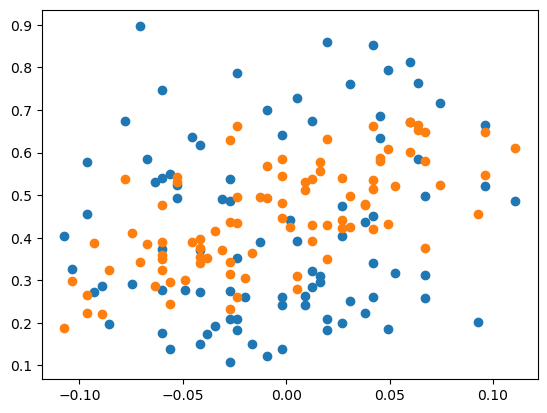

In [39]:
# 예측값과 정답을 시각화해서 비교해보기

import matplotlib.pyplot as plt

plt.scatter(X_test[:, 0], y_test)
plt.scatter(X_test[:, 0], prediction)
plt.show()